# Step 0: Setup Environment — Hybrid Predictive Maintenance (FD004)

In [1]:
# Step 0: Setup Environment — Hybrid Predictive Maintenance (FD004)

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Set Seaborn and Matplotlib Plot Styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 3. Create Required Output Directories
required_dirs = [
    os.path.join('..', '..', 'figures', 'phase3'),
    os.path.join('..', '..', 'models'),
    os.path.join('..', '..', 'report')
]

for path in required_dirs:
    os.makedirs(path, exist_ok=True)
    print(f"Directory ensured: {path}")

# 4. Set Global Random Seed for Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n✅ Step 0 Complete — FD004 environment setup is ready.\n")


Directory ensured: ..\..\figures\phase3
Directory ensured: ..\..\models
Directory ensured: ..\..\report

✅ Step 0 Complete — FD004 environment setup is ready.



# Step 1: Load Corrected Dataset (FD004)

In [2]:
# Step 1: Load Corrected Dataset (FD004)

import pandas as pd
import os

# 1. Define the file path for FD004
data_path_fd004 = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD004.csv')

# 2. Load the FD004 dataset
df_fd004 = pd.read_csv(data_path_fd004)
print(f"Dataset loaded: {data_path_fd004}")

# 3. Preview the first few rows
print("\nPreview of first 5 rows:")
display(df_fd004.head())

# 4. Display dataset structure
print("\nDataset Info:")
print(df_fd004.info())

# 5. Print all available column names
print("\nAvailable Columns:")
print(df_fd004.columns.tolist())

# 6. Show class distribution for the k-means stage labels
print("\nClass Distribution (kmeans_stage):")
print(df_fd004['kmeans_stage'].value_counts().sort_index())


Dataset loaded: ..\..\data\corrected_clustered_train_FD004.csv

Preview of first 5 rows:


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_20,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2
0,1,1,42.0049,0.8400,100.0,0.000000,0.130347,0.272082,0.212586,0.000000,...,0.015473,0.015881,0,0,Stage 0,Stage 0,-0.978075,0.602999,-105.088400,-1.047405
1,1,2,20.0020,0.7002,100.0,0.626985,0.647971,0.634407,0.511781,0.507937,...,0.477968,0.481487,4,4,Stage 4,Stage 4,0.430624,0.142024,22.546156,2.764197
2,1,3,42.0038,0.8409,100.0,0.000000,0.123646,0.271245,0.222481,0.000000,...,0.010764,0.018932,0,0,Stage 0,Stage 0,-0.987515,0.593108,-107.455940,-4.165714
3,1,4,42.0000,0.8400,100.0,0.000000,0.121351,0.266168,0.224835,0.000000,...,0.012782,0.018724,0,0,Stage 0,Stage 0,-0.976725,0.602281,-71.375750,-13.750479
4,1,5,25.0063,0.6207,60.0,0.238089,0.005691,0.033916,0.022025,0.293184,...,0.130172,0.145560,3,2,Stage 3,Stage 2,-1.741788,-1.239966,-37.748306,-102.232735



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            61249 non-null  int64  
 1   time            61249 non-null  int64  
 2   op_setting_1    61249 non-null  float64
 3   op_setting_2    61249 non-null  float64
 4   op_setting_3    61249 non-null  float64
 5   sensor_1        61249 non-null  float64
 6   sensor_2        61249 non-null  float64
 7   sensor_3        61249 non-null  float64
 8   sensor_4        61249 non-null  float64
 9   sensor_5        61249 non-null  float64
 10  sensor_6        61249 non-null  float64
 11  sensor_7        61249 non-null  float64
 12  sensor_8        61249 non-null  float64
 13  sensor_9        61249 non-null  float64
 14  sensor_10       61249 non-null  float64
 15  sensor_11       61249 non-null  float64
 16  sensor_12       61249 non-null  float64
 17  sensor_13       

# Step 1.5: Add Rolling Statistics — Feature Engineering (FD004)

In [3]:
# Step 1.5: Add Rolling Statistics — Feature Engineering (FD004)

ROLLING_WINDOW = 5
rolling_sensors_fd004 = ['sensor_16', 'sensor_1', 'sensor_19', 'sensor_13', 'sensor_2']

# Compute rolling mean and std for each sensor grouped by engine unit
for sensor in rolling_sensors_fd004:
    df_fd004[f'{sensor}_roll_mean'] = df_fd004.groupby('unit')[sensor].rolling(
        window=ROLLING_WINDOW, min_periods=1).mean().reset_index(drop=True)
    df_fd004[f'{sensor}_roll_std'] = df_fd004.groupby('unit')[sensor].rolling(
        window=ROLLING_WINDOW, min_periods=1).std().reset_index(drop=True).fillna(0)

print("Rolling mean and std features added for top-variance sensors in FD004.")


Rolling mean and std features added for top-variance sensors in FD004.


# Step 2: Feature & Label Extraction + StandardScaler Setup (FD004)


In [4]:
# Step 2: Feature & Label Extraction + StandardScaler Setup (FD004)

from sklearn.preprocessing import StandardScaler

# 1. Top 5 high-variance sensors for FD004
base_features_fd004 = ['sensor_16', 'sensor_1', 'sensor_19', 'sensor_13', 'sensor_2']

# 2. Add corresponding rolling mean and std features
rolling_features_fd004 = [f"{sensor}_roll_mean" for sensor in base_features_fd004] + \
                         [f"{sensor}_roll_std" for sensor in base_features_fd004]

# 3. Combine all features into a single list
selected_features_fd004 = base_features_fd004 + rolling_features_fd004

# 4. Extract Features (X) and Labels (y)
X_fd004 = df_fd004[selected_features_fd004]
y_fd004 = df_fd004['kmeans_stage']

# 5. Output shapes and preview
print("Shape of Feature Set X:", X_fd004.shape)
print("Shape of Target y:", y_fd004.shape)

print("\nPreview of selected features:")
display(X_fd004.head())

print("\nClass Distribution in y (FD004):")
print(y_fd004.value_counts().sort_index())

# 6. Initialize StandardScaler
scaler_fd004 = StandardScaler()
print("\nStandardScaler initialized — will be fitted only on training data.")


Shape of Feature Set X: (61249, 15)
Shape of Target y: (61249,)

Preview of selected features:


,sensor_16,sensor_1,sensor_19,sensor_13,sensor_2,sensor_16_roll_mean,sensor_1_roll_mean,sensor_19_roll_mean,sensor_13_roll_mean,sensor_2_roll_mean,sensor_16_roll_std,sensor_1_roll_std,sensor_19_roll_std,sensor_13_roll_std,sensor_2_roll_std
0,0.0,0.000000,1.0,0.993111,0.130347,0.0,0.000000,1.0,0.993111,0.130347,0.0,0.000000,0.000000,0.000000,0.000000
1,0.0,0.626985,1.0,0.992395,0.647971,0.0,0.313493,1.0,0.992753,0.389159,0.0,0.443345,0.000000,0.000507,0.366016
2,0.0,0.000000,1.0,0.993056,0.123646,0.0,0.208995,1.0,0.992854,0.300655,0.0,0.361990,0.000000,0.000399,0.300804
3,0.0,0.000000,1.0,0.993194,0.121351,0.0,0.156746,1.0,0.992939,0.255829,0.0,0.313493,0.000000,0.000367,0.261456
4,0.0,0.238089,0.0,0.001405,0.005691,0.0,0.173015,0.8,0.794632,0.205801,0.0,0.273919,0.447214,0.443428,0.252553



Class Distribution in y (FD004):
kmeans_stage
Stage 0    24557
Stage 1     9238
Stage 2    10683
Stage 3     9139
Stage 4     7632
Name: count, dtype: int64

StandardScaler initialized — will be fitted only on training data.


In [ ]:
# Step 3: Train-Test Split + Scaling + SMOTE (FD004)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Set test size and random state
TEST_SIZE = 0.20
RANDOM_STATE = 42

# 2. Stratified Train/Test Split
X_train_fd004, X_test_fd004, y_train_fd004, y_test_fd004 = train_test_split(
    X_fd004,
    y_fd004,
    test_size=TEST_SIZE,
    stratify=y_fd004,
    random_state=RANDOM_STATE
)

# 3. Show Shapes
print(" X_train:", X_train_fd004.shape)
print(" X_test :", X_test_fd004.shape)
print(" y_train:", y_train_fd004.shape)
print(" y_test :", y_test_fd004.shape)

# 4. Class Distribution Check
print("\n Class Distribution in y_train:")
print(y_train_fd004.value_counts(normalize=True).sort_index())

print("\n Class Distribution in y_test:")
print(y_test_fd004.value_counts(normalize=True).sort_index())

# 5. Fit + Transform with Pre-initialized Scaler (scaled only after train-test split)
X_train_scaled_fd004 = scaler_fd004.fit_transform(X_train_fd004)
X_test_scaled_fd004 = scaler_fd004.transform(X_test_fd004)

print("\n StandardScaler fitted on X_train and applied to X_train and X_test.")

# 6. Apply SMOTE to balance classes in training set
smote = SMOTE(random_state=RANDOM_STATE)

# For unscaled data (used in Random Forest, XGBoost)
X_train_bal_fd004, y_train_bal_fd004 = smote.fit_resample(X_train_fd004, y_train_fd004)

# For scaled data (used in SVM, Logistic Regression)
X_train_scaled_bal_fd004, y_train_bal_fd004 = smote.fit_resample(X_train_scaled_fd004, y_train_fd004)

# 7. Confirm SMOTE balancing
print("\n Class distribution after SMOTE (Unscaled):")
print(pd.Series(y_train_bal_fd004).value_counts().sort_index())


# Step 3: Train-Test Split + Scaling + SMOTE (FD004)

In [5]:
# Step 3: Train-Test Split + Scaling + SMOTE (FD004)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Set constants
TEST_SIZE = 0.20
RANDOM_STATE = 42

# 2. Train/Test split (Stratified)
X_train_fd004, X_test_fd004, y_train_fd004, y_test_fd004 = train_test_split(
    X_fd004,
    y_fd004,
    test_size=TEST_SIZE,
    stratify=y_fd004,
    random_state=RANDOM_STATE
)

# 3. Display shape summary
print("X_train shape:", X_train_fd004.shape)
print("X_test  shape:", X_test_fd004.shape)
print("y_train shape:", y_train_fd004.shape)
print("y_test  shape:", y_test_fd004.shape)

# 4. Show class distribution before SMOTE
print("\nClass Distribution in y_train (Before SMOTE):")
print(y_train_fd004.value_counts(normalize=True).sort_index())

print("\nClass Distribution in y_test:")
print(y_test_fd004.value_counts(normalize=True).sort_index())

# 5. Apply StandardScaler (on training only)
X_train_scaled_fd004 = scaler_fd004.fit_transform(X_train_fd004)
X_test_scaled_fd004 = scaler_fd004.transform(X_test_fd004)

print("\nStandardScaler fitted on X_train and applied to both X_train and X_test.")

# 6. Apply SMOTE to balance classes in training set
smote = SMOTE(random_state=RANDOM_STATE)

# a) For unscaled data (used for Random Forest, XGBoost)
X_train_bal_fd004, y_train_bal_fd004 = smote.fit_resample(X_train_fd004, y_train_fd004)

# b) For scaled data (used for SVM, Logistic Regression)
X_train_scaled_bal_fd004, y_train_bal_fd004 = smote.fit_resample(X_train_scaled_fd004, y_train_fd004)

# 7. Confirm post-SMOTE class balance
print("\nClass distribution after SMOTE (on unscaled training set):")
print(pd.Series(y_train_bal_fd004).value_counts().sort_index())


X_train shape: (48999, 15)
X_test  shape: (12250, 15)
y_train shape: (48999,)
y_test  shape: (12250,)

Class Distribution in y_train (Before SMOTE):
kmeans_stage
Stage 0    0.400947
Stage 1    0.150819
Stage 2    0.174412
Stage 3    0.149207
Stage 4    0.124615
Name: proportion, dtype: float64

Class Distribution in y_test:
kmeans_stage
Stage 0    0.400898
Stage 1    0.150857
Stage 2    0.174449
Stage 3    0.149224
Stage 4    0.124571
Name: proportion, dtype: float64

StandardScaler fitted on X_train and applied to both X_train and X_test.

Class distribution after SMOTE (on unscaled training set):
kmeans_stage
Stage 0    19646
Stage 1    19646
Stage 2    19646
Stage 3    19646
Stage 4    19646
Name: count, dtype: int64


# Step 3.1: Sanity Checks & Remove Duplicates + Overlap — FD004

In [6]:
# Step 3.1: Sanity Checks & Remove Duplicates + Overlap — FD004

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Create DataFrames from original splits with column names
X_train_df_fd004 = pd.DataFrame(X_train_fd004, columns=X_fd004.columns)
X_test_df_fd004 = pd.DataFrame(X_test_fd004, columns=X_fd004.columns)

# Add corresponding labels to each
X_train_df_fd004['label'] = y_train_fd004.values
X_test_df_fd004['label'] = y_test_fd004.values

# Step 1: Drop exact duplicates
X_train_df_fd004 = X_train_df_fd004.drop_duplicates()
X_test_df_fd004 = X_test_df_fd004.drop_duplicates()

# Step 2: Find and remove overlapping rows from training data
overlap_fd004 = pd.merge(
    X_train_df_fd004.drop(columns='label'),
    X_test_df_fd004.drop(columns='label'),
    how='inner',
    on=X_fd004.columns.tolist()
)

X_train_df_fd004 = X_train_df_fd004.merge(
    overlap_fd004,
    how='outer',
    on=X_fd004.columns.tolist(),
    indicator=True
)

X_train_df_fd004 = X_train_df_fd004[X_train_df_fd004['_merge'] == 'left_only'].drop(columns=['_merge'])

# Step 3: Extract cleaned arrays
X_train_fd004_clean = X_train_df_fd004.drop(columns='label').values
y_train_fd004_clean = X_train_df_fd004['label'].values
X_test_fd004_clean = X_test_df_fd004.drop(columns='label').values
y_test_fd004_clean = X_test_df_fd004['label'].values

# Step 4: Refit StandardScaler on cleaned training set
scaler_fd004 = StandardScaler()
X_train_scaled_fd004_clean = scaler_fd004.fit_transform(X_train_fd004_clean)
X_test_scaled_fd004_clean = scaler_fd004.transform(X_test_fd004_clean)

# Final Output
print("Cleaned FD004 training data — duplicates removed and overlaps with test set excluded.")
print(f"Final X_train_fd004_clean shape: {X_train_fd004_clean.shape}")
print(f"Final X_test_fd004_clean  shape: {X_test_fd004_clean.shape}")


Cleaned FD004 training data — duplicates removed and overlaps with test set excluded.
Final X_train_fd004_clean shape: (48999, 15)
Final X_test_fd004_clean  shape: (12250, 15)


# Step 3.2: Apply SMOTE to Cleaned FD004 Data

In [7]:
# Step 3.2: Apply SMOTE to Cleaned FD004 Data

from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Apply to unscaled cleaned training data (used for Random Forest, XGBoost)
X_train_bal_fd004, y_train_bal_fd004 = smote.fit_resample(X_train_fd004_clean, y_train_fd004_clean)

# 3. Apply to scaled cleaned training data (used for SVM, Logistic Regression)
X_train_scaled_bal_fd004, y_train_bal_fd004 = smote.fit_resample(X_train_scaled_fd004_clean, y_train_fd004_clean)

# 4. Show class distribution
print("Class distribution after SMOTE (FD004, Cleaned):")
print(pd.Series(y_train_bal_fd004).value_counts().sort_index())


Class distribution after SMOTE (FD004, Cleaned):
Stage 0    19646
Stage 1    19646
Stage 2    19646
Stage 3    19646
Stage 4    19646
Name: count, dtype: int64


# Step 3.3: Sanity Checks for FD004 (Cleaned)

Train Labels: ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
Test Labels : ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
Overlapping Classes: {'Stage 3', 'Stage 4', 'Stage 2', 'Stage 1', 'Stage 0'}

Class distribution in y_train_fd004_clean:
Stage 0    0.400947
Stage 1    0.150819
Stage 2    0.174412
Stage 3    0.149207
Stage 4    0.124615
Name: proportion, dtype: float64

Class distribution in y_test_fd004_clean:
Stage 0    0.400898
Stage 1    0.150857
Stage 2    0.174449
Stage 3    0.149224
Stage 4    0.124571
Name: proportion, dtype: float64

CV F1 Macro Scores (Train Set): [1. 1. 1. 1. 1.]
Mean F1 Macro Score: 1.0

Overlap rows between train and test: 0


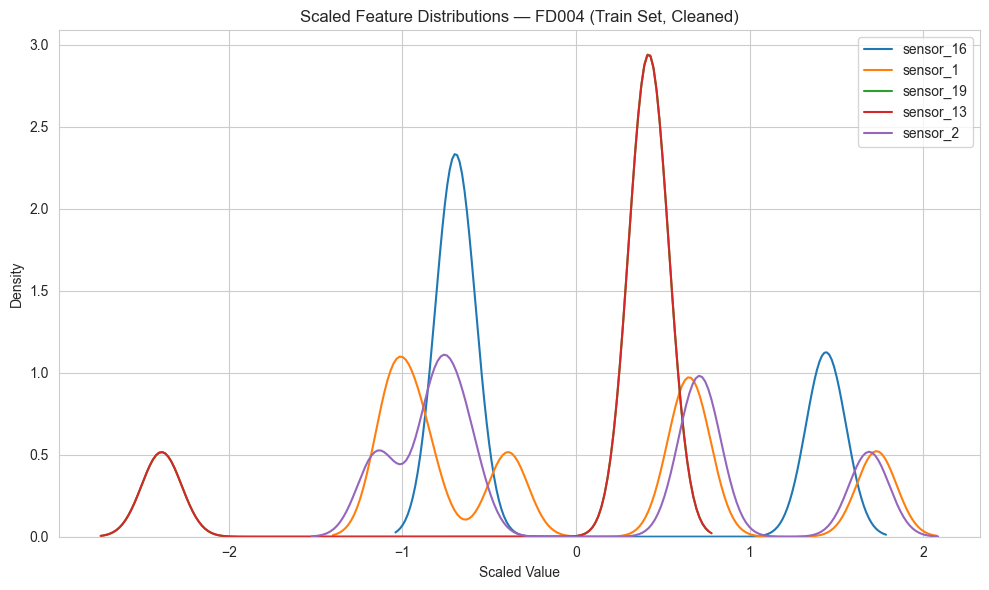

In [8]:
# Step 3.3: Sanity Checks for FD004 (Cleaned)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Set random state
RANDOM_STATE = 42
top5_sensors_fd004 = ['sensor_16', 'sensor_1', 'sensor_19', 'sensor_13', 'sensor_2']

# A. Train/Test labels
print("Train Labels:", sorted(np.unique(y_train_fd004_clean)))
print("Test Labels :", sorted(np.unique(y_test_fd004_clean)))
print("Overlapping Classes:", set(y_train_fd004_clean) & set(y_test_fd004_clean))

# B. Distribution check
print("\nClass distribution in y_train_fd004_clean:")
print(pd.Series(y_train_fd004_clean).value_counts(normalize=True).sort_index())

print("\nClass distribution in y_test_fd004_clean:")
print(pd.Series(y_test_fd004_clean).value_counts(normalize=True).sort_index())

# C. CV on training only — using RandomForest with 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_model_fd004 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf_model_fd004,
    X_train_fd004_clean,
    y_train_fd004_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("\nCV F1 Macro Scores (Train Set):", cv_scores)
print("Mean F1 Macro Score:", np.mean(cv_scores))

# D. Overlap check between cleaned train and test sets
train_rows = set(map(tuple, X_train_fd004_clean))
test_rows = set(map(tuple, X_test_fd004_clean))
overlap_count = len(train_rows & test_rows)
print(f"\nOverlap rows between train and test: {overlap_count}")

# E. Visual Check: KDE of Scaled Feature Distributions
plt.figure(figsize=(10, 6))
for i, sensor in enumerate(top5_sensors_fd004):
    sns.kdeplot(X_train_scaled_fd004_clean[:, i], label=sensor)

plt.title("Scaled Feature Distributions — FD004 (Train Set, Cleaned)")
plt.xlabel("Scaled Value")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 3.4: Clean Train/Test Data + Refit Scaler (FD004)

In [9]:
# Step 3.4: Clean Train/Test Data + Refit Scaler (FD004)

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Top 5 variance sensors for FD004
top5_sensors_fd004 = ['sensor_16', 'sensor_1', 'sensor_19', 'sensor_13', 'sensor_2']

# 1. Prepare train DataFrame with label
X_train_df = pd.DataFrame(X_train_fd004, columns=top5_sensors_fd004)
X_train_df['label'] = y_train_fd004.values

# 2. Drop duplicates
X_train_df = X_train_df.drop_duplicates()

# 3. Extract cleaned train arrays
X_train_fd004_clean = X_train_df.drop(columns='label').values
y_train_fd004_clean = X_train_df['label'].values

# 4. Prepare test DataFrame and remove overlaps
X_test_df = pd.DataFrame(X_test_fd004, columns=top5_sensors_fd004)
X_test_df['label'] = y_test_fd004.values

train_set = set(map(tuple, X_train_fd004_clean))
X_test_df = X_test_df[~X_test_df[top5_sensors_fd004].apply(tuple, axis=1).isin(train_set)]

# 5. Extract cleaned test arrays
X_test_fd004_clean = X_test_df[top5_sensors_fd004].values
y_test_fd004_clean = X_test_df['label'].values

# 6. Refit StandardScaler on cleaned training set
scaler_fd004 = StandardScaler()
X_train_scaled_fd004_clean = scaler_fd004.fit_transform(X_train_fd004_clean)
X_test_scaled_fd004_clean = scaler_fd004.transform(X_test_fd004_clean)

# 7. Final status
print("Data leakage & duplicates removed successfully (FD004).")
print("Final Clean Shapes:")
print(f"  X_train_fd004_clean: {X_train_fd004_clean.shape}")
print(f"  X_test_fd004_clean : {X_test_fd004_clean.shape}")


Data leakage & duplicates removed successfully (FD004).
Final Clean Shapes:
  X_train_fd004_clean: (31954, 5)
  X_test_fd004_clean : (5473, 5)


# Step 4: Random Forest Training, Evaluation, and Sanity Checks — FD004


 RF 5-Fold CV F1 Macro Scores (FD004, Cleaned): [1. 1. 1. 1. 1.]
 Mean F1 Macro Score: 1.0
 RF model saved at: ..\..\models\rf_fd004_model.pkl


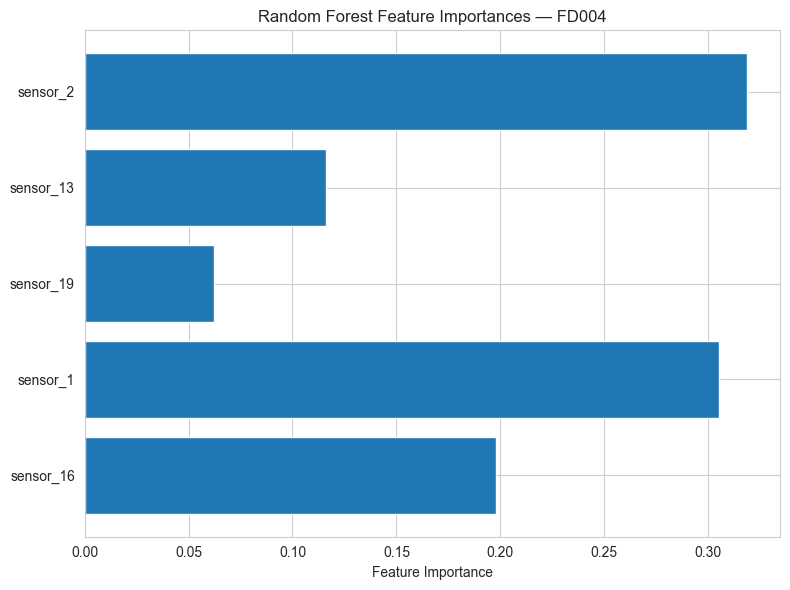

 Feature importance plot saved at: ..\..\figures\phase3\rf_fd004_feature_importances.png

 RF Test Accuracy: 1.0000
 RF Test Classification Report:

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      2278
     Stage 1       1.00      1.00      1.00       625
     Stage 2       1.00      1.00      1.00      1034
     Stage 3       1.00      1.00      1.00       860
     Stage 4       1.00      1.00      1.00       676

    accuracy                           1.00      5473
   macro avg       1.00      1.00      1.00      5473
weighted avg       1.00      1.00      1.00      5473



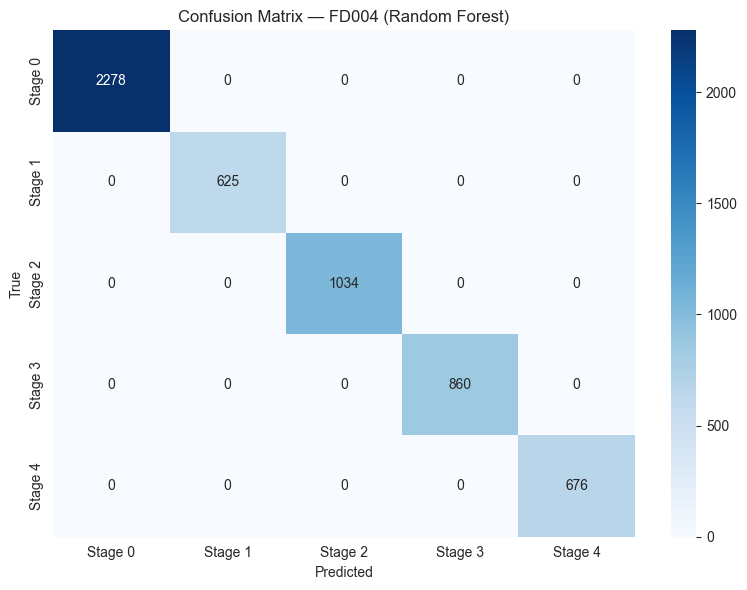

 Confusion matrix saved at: ..\..\figures\phase3\rf_fd004_confusion_matrix.png

 Sanity Check A — CV with Shuffled Labels
 CV F1 Scores (shuffled): [0.2052732  0.19120036 0.20053901 0.19736624 0.19390786]
 Mean F1 (shuffled): 0.19765733414455505

 Sanity Check B — Feature Correlation to Stage Label
 sensor_16 → Pearson correlation: 0.0566
 sensor_1 → Pearson correlation: 0.4742
 sensor_19 → Pearson correlation: -0.4447
 sensor_13 → Pearson correlation: -0.4447
 sensor_2 → Pearson correlation: 0.2642

 Sanity Check C — Depth=2 Decision Tree
 Tiny Tree Accuracy → Train: 0.7399 | Test: 0.7623


In [10]:
# Step 4: Random Forest Training, Evaluation, and Sanity Checks — FD004

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import shuffle
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Top 5 variance sensors for FD004
top5_sensors_fd004 = ['sensor_16', 'sensor_1', 'sensor_19', 'sensor_13', 'sensor_2']

# 1. Ensure model and figure directories exist
os.makedirs('../../models', exist_ok=True)
os.makedirs('../../figures/phase3', exist_ok=True)

# 2. Initialize Random Forest
rf_model_fd004 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 3. Stratified 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf_fd004 = cross_val_score(
    rf_model_fd004,
    X_train_scaled_fd004_clean,
    y_train_fd004_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print(" RF 5-Fold CV F1 Macro Scores (FD004, Cleaned):", cv_scores_rf_fd004)
print(" Mean F1 Macro Score:", np.mean(cv_scores_rf_fd004))

# 4. Train on full cleaned training set
rf_model_fd004.fit(X_train_scaled_fd004_clean, y_train_fd004_clean)

# 5. Save trained model
model_path = os.path.join('..', '..', 'models', 'rf_fd004_model.pkl')
joblib.dump(rf_model_fd004, model_path)
print(f" RF model saved at: {model_path}")

# 6. Plot feature importances
importances = rf_model_fd004.feature_importances_
plt.figure(figsize=(8, 6))
plt.barh(top5_sensors_fd004, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances — FD004")
plt.tight_layout()
plot_path = os.path.join('..', '..', 'figures', 'phase3', 'rf_fd004_feature_importances.png')
plt.savefig(plot_path)
plt.show()
print(f" Feature importance plot saved at: {plot_path}")

# 7. Evaluation on test set
y_test_pred_rf = rf_model_fd004.predict(X_test_scaled_fd004_clean)
test_acc = accuracy_score(y_test_fd004_clean, y_test_pred_rf)
print(f"\n RF Test Accuracy: {test_acc:.4f}")
print(" RF Test Classification Report:\n")
print(classification_report(y_test_fd004_clean, y_test_pred_rf))

# 8. Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test_fd004_clean, y_test_pred_rf),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=rf_model_fd004.classes_,
    yticklabels=rf_model_fd004.classes_
)
plt.title("Confusion Matrix — FD004 (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
cm_path = os.path.join('..', '..', 'figures', 'phase3', 'rf_fd004_confusion_matrix.png')
plt.savefig(cm_path)
plt.show()
print(f" Confusion matrix saved at: {cm_path}")

# 9. Sanity Check A: Shuffled Labels
print("\n Sanity Check A — CV with Shuffled Labels")
y_shuffled = shuffle(y_train_fd004_clean, random_state=42)
rf_shuffled = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
cv_shuffled = cross_val_score(rf_shuffled, X_train_scaled_fd004_clean, y_shuffled, cv=skf, scoring='f1_macro')
print(" CV F1 Scores (shuffled):", cv_shuffled)
print(" Mean F1 (shuffled):", np.mean(cv_shuffled))

# 10. Sanity Check B: Sensor Correlation to Label
print("\n Sanity Check B — Feature Correlation to Stage Label")
y_stage_numeric = pd.Series(y_train_fd004_clean).apply(lambda x: int(x[-1]))
for sensor in top5_sensors_fd004:
    idx = top5_sensors_fd004.index(sensor)
    corr = pd.Series(X_train_scaled_fd004_clean[:, idx]).corr(y_stage_numeric)
    print(f" {sensor} → Pearson correlation: {corr:.4f}")

# 11. Sanity Check C: Tiny Decision Tree (Depth=2)
print("\n Sanity Check C — Depth=2 Decision Tree")
tiny_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tiny_tree.fit(X_train_scaled_fd004_clean, y_train_fd004_clean)
train_score = tiny_tree.score(X_train_scaled_fd004_clean, y_train_fd004_clean)
test_score = tiny_tree.score(X_test_scaled_fd004_clean, y_test_fd004_clean)
print(f" Tiny Tree Accuracy → Train: {train_score:.4f} | Test: {test_score:.4f}")


# Step 5: Final Evaluation of Random Forest on FD004 (Cleaned)

RF Train Accuracy: 1.0000
RF Test Accuracy : 1.0000
Reports saved at:
- c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd004_train_classification_report.txt
- c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd004_test_classification_report.txt


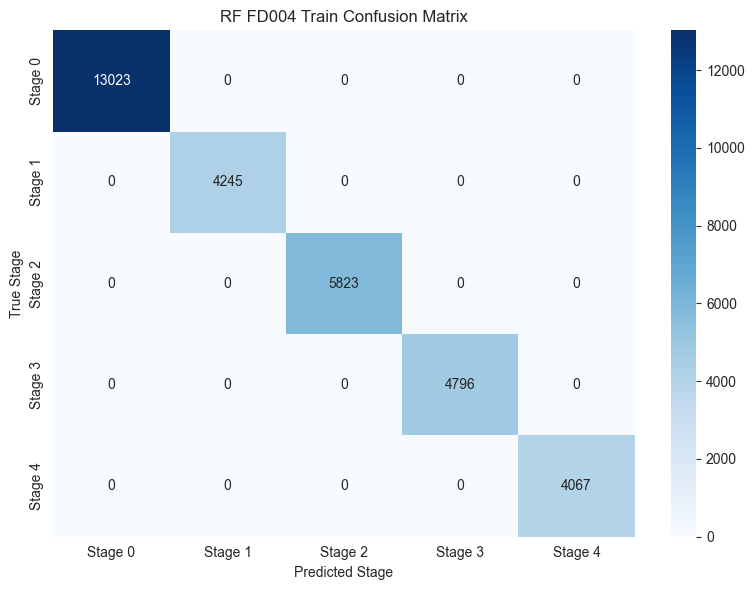

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_train_conf_matrix.png


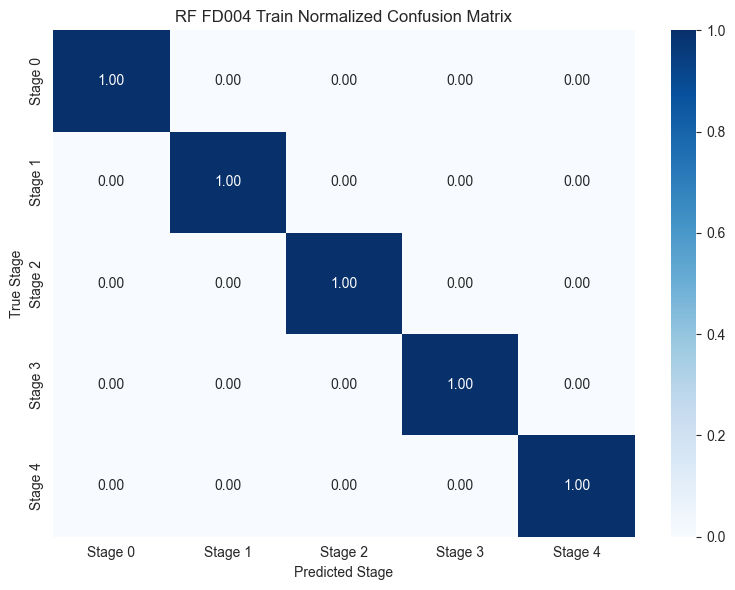

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_train_conf_matrix_normalized.png


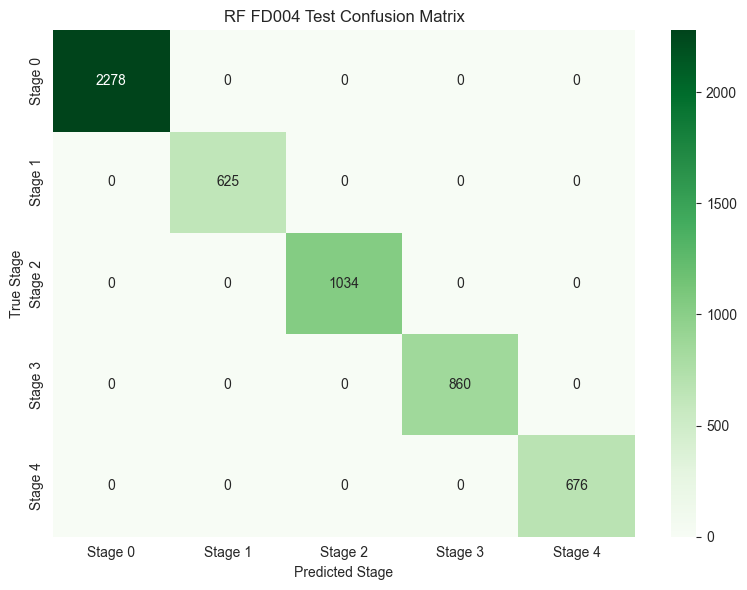

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_test_conf_matrix.png


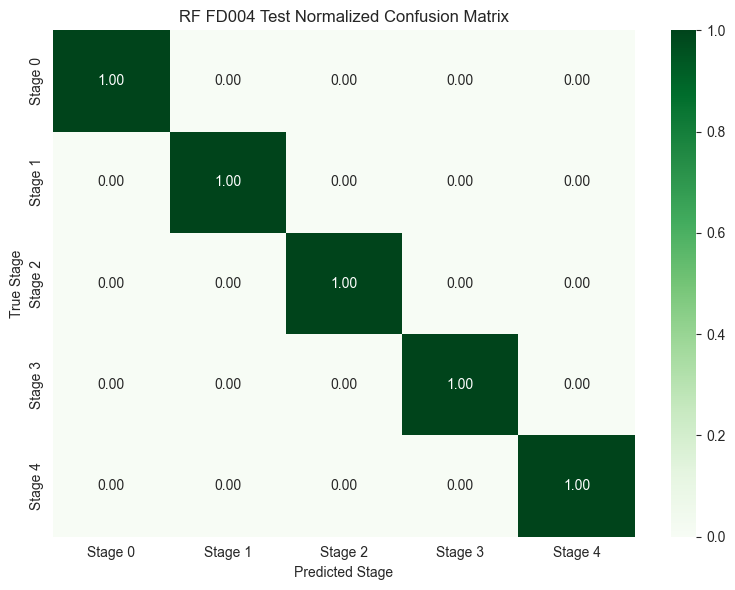

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_test_conf_matrix_normalized.png


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# 1. Load trained RF model (FD004)
model_path = os.path.join('..', '..', 'models', 'rf_fd004_model.pkl')
rf_model_fd004 = joblib.load(model_path)

# 2. Predict on cleaned, scaled train and test sets
y_train_pred_rf_fd004 = rf_model_fd004.predict(X_train_scaled_fd004_clean)
y_test_pred_rf_fd004 = rf_model_fd004.predict(X_test_scaled_fd004_clean)

# 3. Accuracy scores
train_acc = accuracy_score(y_train_fd004_clean, y_train_pred_rf_fd004)
test_acc = accuracy_score(y_test_fd004_clean, y_test_pred_rf_fd004)
print(f"RF Train Accuracy: {train_acc:.4f}")
print(f"RF Test Accuracy : {test_acc:.4f}")

# 4. Save classification reports
report_dir = os.path.abspath(os.path.join('..', '..', 'report'))
os.makedirs(report_dir, exist_ok=True)

train_report_path = os.path.join(report_dir, 'rf_fd004_train_classification_report.txt')
test_report_path = os.path.join(report_dir, 'rf_fd004_test_classification_report.txt')

with open(train_report_path, 'w') as f:
    f.write(classification_report(y_train_fd004_clean, y_train_pred_rf_fd004))

with open(test_report_path, 'w') as f:
    f.write(classification_report(y_test_fd004_clean, y_test_pred_rf_fd004))

print(f"Reports saved at:\n- {train_report_path}\n- {test_report_path}")

# 5. Define helper to save confusion matrix
figures_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(figures_dir, exist_ok=True)

def save_conf_matrix(cm, title, filename, fmt='d', cmap='Blues'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=rf_model_fd004.classes_,
                yticklabels=rf_model_fd004.classes_)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    path = os.path.join(figures_dir, filename)
    plt.savefig(path)
    plt.show()
    print(f"Saved: {path}")

# 6. Train Confusion Matrices
cm_train_fd004 = confusion_matrix(y_train_fd004_clean, y_train_pred_rf_fd004)
cm_train_norm_fd004 = confusion_matrix(y_train_fd004_clean, y_train_pred_rf_fd004, normalize='true')
save_conf_matrix(cm_train_fd004, "RF FD004 Train Confusion Matrix", "rf_fd004_train_conf_matrix.png", 'd', 'Blues')
save_conf_matrix(cm_train_norm_fd004, "RF FD004 Train Normalized Confusion Matrix", "rf_fd004_train_conf_matrix_normalized.png", '.2f', 'Blues')

# 7. Test Confusion Matrices
cm_test_fd004 = confusion_matrix(y_test_fd004_clean, y_test_pred_rf_fd004)
cm_test_norm_fd004 = confusion_matrix(y_test_fd004_clean, y_test_pred_rf_fd004, normalize='true')
save_conf_matrix(cm_test_fd004, "RF FD004 Test Confusion Matrix", "rf_fd004_test_conf_matrix.png", 'd', 'Greens')
save_conf_matrix(cm_test_norm_fd004, "RF FD004 Test Normalized Confusion Matrix", "rf_fd004_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step 6: SVM Classifier + CV + Evaluation (FD004, Cleaned)

SVM 5-Fold CV F1 Macro Scores (FD004): [1. 1. 1. 1. 1.]
Mean F1 Macro Score: 1.0
SVM model saved at: ..\..\models\svm_fd004_model.pkl
SVM Train Accuracy: 1.0000
SVM Test Accuracy : 1.0000
Classification reports saved.


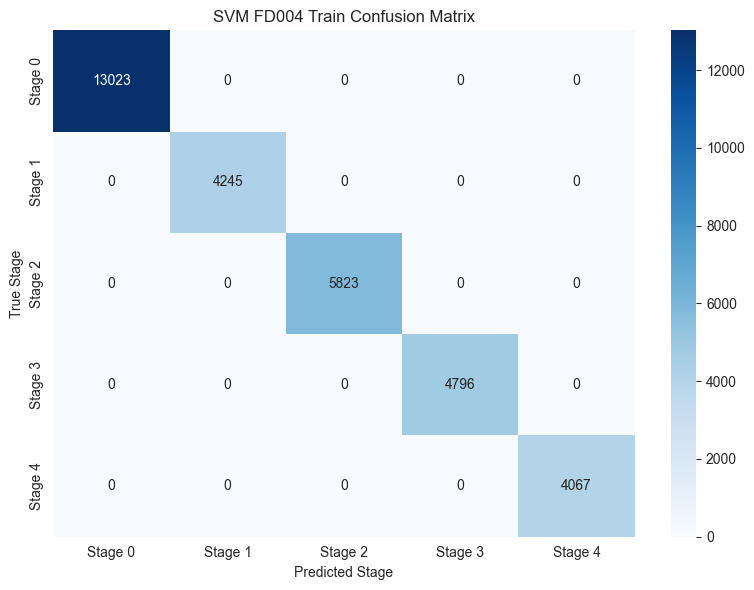

Saved: ..\..\figures\phase3\svm_fd004_train_conf_matrix.png


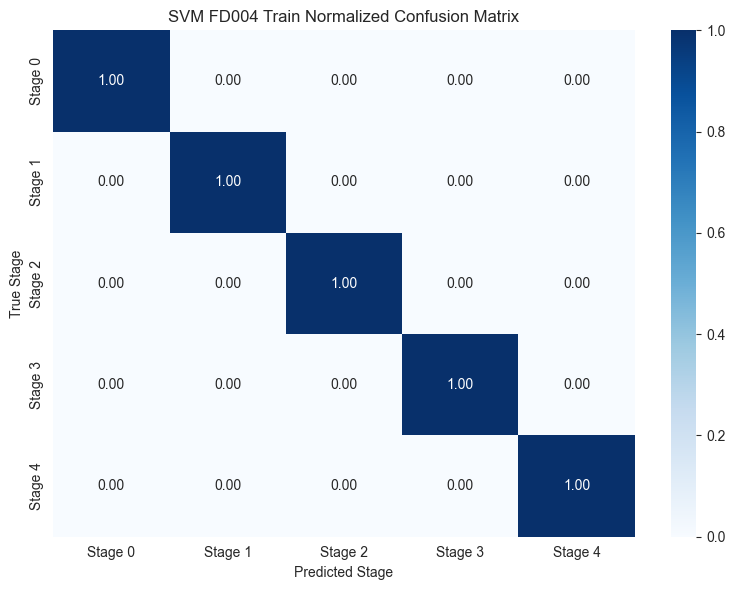

Saved: ..\..\figures\phase3\svm_fd004_train_conf_matrix_normalized.png


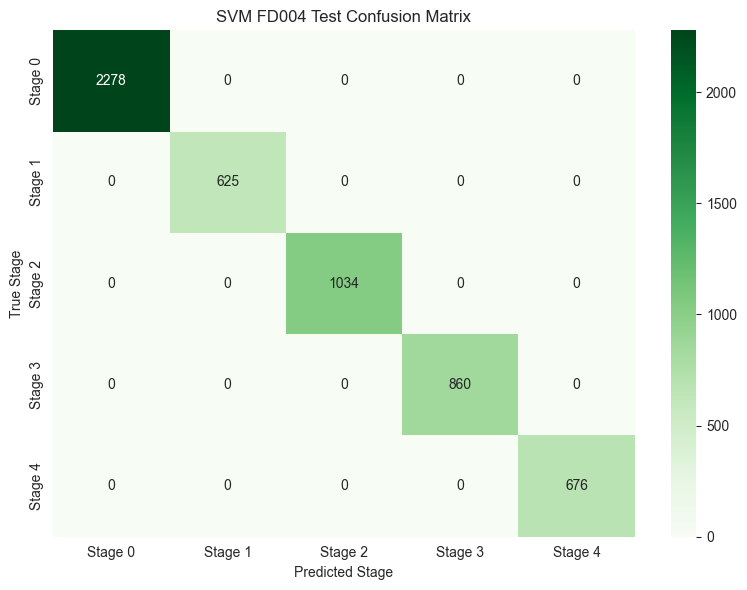

Saved: ..\..\figures\phase3\svm_fd004_test_conf_matrix.png


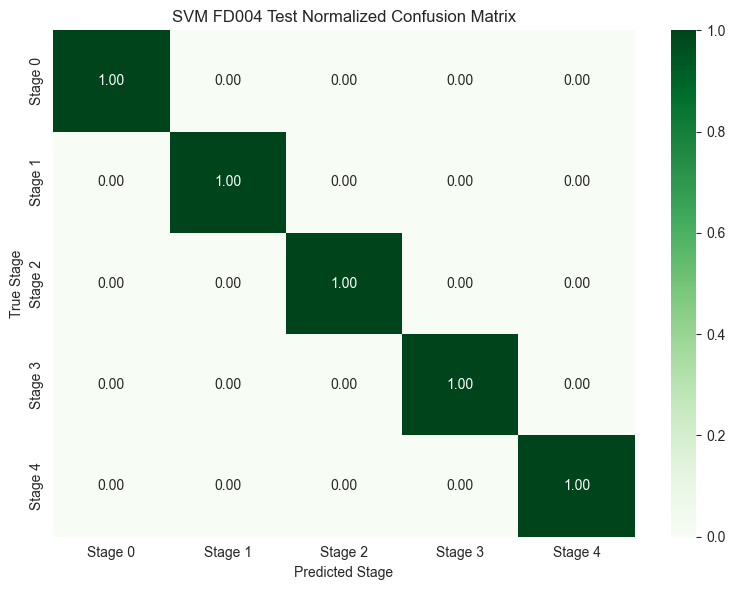

Saved: ..\..\figures\phase3\svm_fd004_test_conf_matrix_normalized.png


In [12]:
# Step 6: SVM Classifier + CV + Evaluation (FD004, Cleaned)

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

# 1. Initialize SVM Classifier
svm_model_fd004 = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=False,
    random_state=42
)

# 2. 5-Fold Cross Validation on Scaled Cleaned Data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_svm_fd004 = cross_val_score(
    svm_model_fd004,
    X_train_scaled_fd004_clean,
    y_train_fd004_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("SVM 5-Fold CV F1 Macro Scores (FD004):", cv_scores_svm_fd004)
print("Mean F1 Macro Score:", np.mean(cv_scores_svm_fd004))

# 3. Train on full cleaned training set
svm_model_fd004.fit(X_train_scaled_fd004_clean, y_train_fd004_clean)

# 4. Save the trained model
model_path = os.path.join('..', '..', 'models', 'svm_fd004_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(svm_model_fd004, model_path)
print(f"SVM model saved at: {model_path}")

# 5. Predict on train and test sets
y_train_pred_svm_fd004 = svm_model_fd004.predict(X_train_scaled_fd004_clean)
y_test_pred_svm_fd004 = svm_model_fd004.predict(X_test_scaled_fd004_clean)

# 6. Accuracy reporting
print(f"SVM Train Accuracy: {accuracy_score(y_train_fd004_clean, y_train_pred_svm_fd004):.4f}")
print(f"SVM Test Accuracy : {accuracy_score(y_test_fd004_clean, y_test_pred_svm_fd004):.4f}")

# 7. Save classification reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'svm_fd004_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd004_clean, y_train_pred_svm_fd004))

with open(os.path.join(report_dir, 'svm_fd004_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd004_clean, y_test_pred_svm_fd004))

print("Classification reports saved.")

# 8. Plot confusion matrices
def plot_conf_matrix(y_true, y_pred, title_prefix, filename_prefix, cmap):
    fig_dir = os.path.join('..', '..', 'figures', 'phase3')
    os.makedirs(fig_dir, exist_ok=True)

    # Raw confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=svm_model_fd004.classes_,
                yticklabels=svm_model_fd004.classes_)
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    raw_path = os.path.join(fig_dir, f"{filename_prefix}.png")
    plt.savefig(raw_path)
    plt.show()
    print(f"Saved: {raw_path}")

    # Normalized confusion matrix
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=svm_model_fd004.classes_,
                yticklabels=svm_model_fd004.classes_)
    plt.title(f"{title_prefix} Normalized Confusion Matrix")
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    norm_path = os.path.join(fig_dir, f"{filename_prefix}_normalized.png")
    plt.savefig(norm_path)
    plt.show()
    print(f"Saved: {norm_path}")

# 9. Plot train and test confusion matrices
plot_conf_matrix(y_train_fd004_clean, y_train_pred_svm_fd004, "SVM FD004 Train", "svm_fd004_train_conf_matrix", 'Blues')
plot_conf_matrix(y_test_fd004_clean, y_test_pred_svm_fd004, "SVM FD004 Test", "svm_fd004_test_conf_matrix", 'Greens')


# Step 7: Logistic Regression Classifier + Evaluation (FD004)


Logistic Regression 5-Fold CV F1 Macro Scores (FD004):
[1. 1. 1. 1. 1.]
Mean F1 Macro Score: 1.0
Trained Logistic Regression model saved at: ..\..\models\lr_fd004_model.pkl
Logistic Regression Train Accuracy: 1.0000
Logistic Regression Test Accuracy : 1.0000
Classification reports saved.


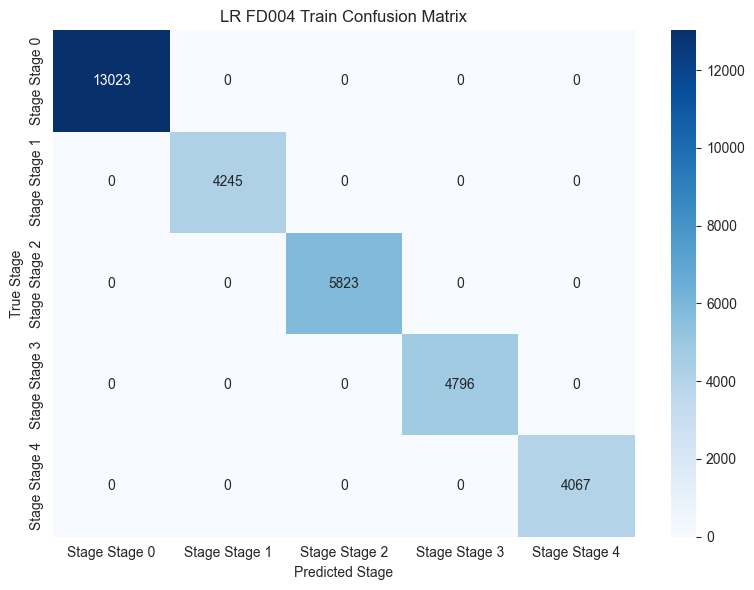

Saved: ..\..\figures\phase3\lr_fd004_train_conf_matrix.png


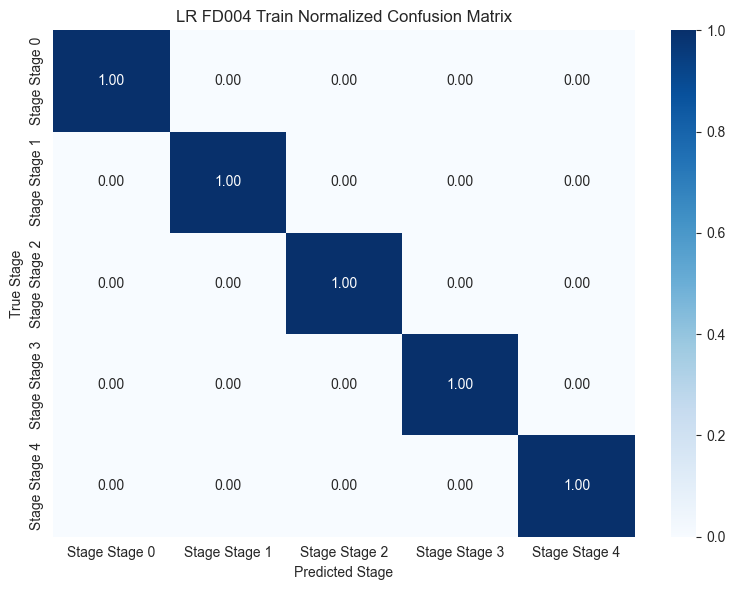

Saved: ..\..\figures\phase3\lr_fd004_train_conf_matrix_normalized.png


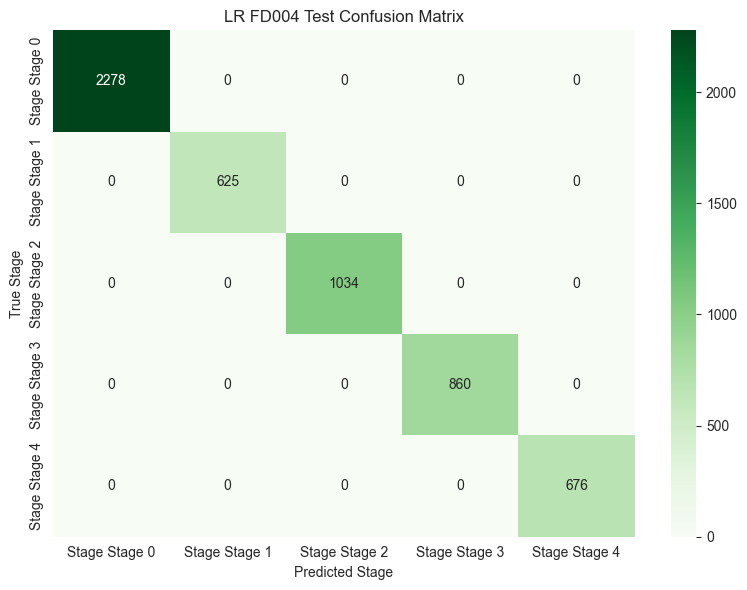

Saved: ..\..\figures\phase3\lr_fd004_test_conf_matrix.png


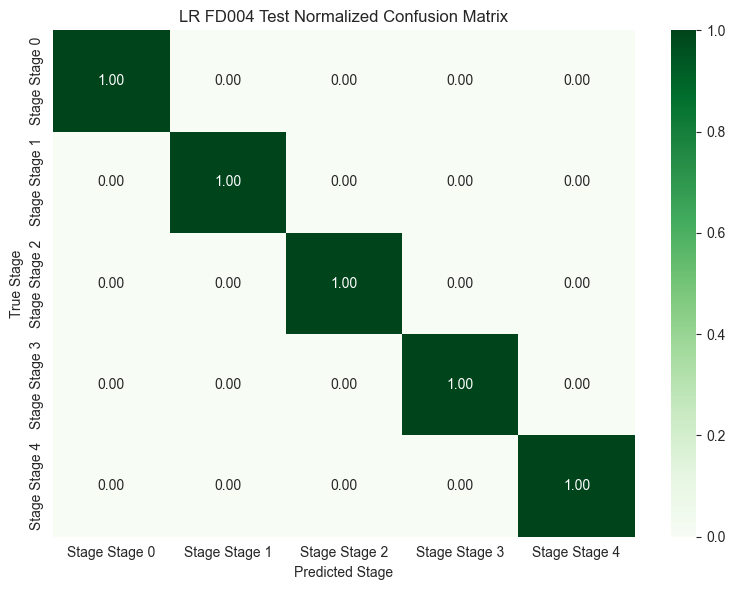

Saved: ..\..\figures\phase3\lr_fd004_test_conf_matrix_normalized.png


In [13]:
# Step 7: Logistic Regression Classifier + Evaluation (FD004)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import numpy as np

# 1. Initialize Logistic Regression Model
lr_model_fd004 = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# 2. Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr_fd004 = cross_val_score(
    lr_model_fd004,
    X_train_scaled_fd004_clean,
    y_train_fd004_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("Logistic Regression 5-Fold CV F1 Macro Scores (FD004):")
print(cv_scores_lr_fd004)
print("Mean F1 Macro Score:", np.mean(cv_scores_lr_fd004))

# 3. Train on Full Cleaned Training Set
lr_model_fd004.fit(X_train_scaled_fd004_clean, y_train_fd004_clean)

# 4. Save Model
model_path = os.path.join('..', '..', 'models', 'lr_fd004_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(lr_model_fd004, model_path)
print(f"Trained Logistic Regression model saved at: {model_path}")

# 5. Predictions
y_train_pred_lr_fd004 = lr_model_fd004.predict(X_train_scaled_fd004_clean)
y_test_pred_lr_fd004 = lr_model_fd004.predict(X_test_scaled_fd004_clean)

print(f"Logistic Regression Train Accuracy: {accuracy_score(y_train_fd004_clean, y_train_pred_lr_fd004):.4f}")
print(f"Logistic Regression Test Accuracy : {accuracy_score(y_test_fd004_clean, y_test_pred_lr_fd004):.4f}")

# 6. Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'lr_fd004_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd004_clean, y_train_pred_lr_fd004))

with open(os.path.join(report_dir, 'lr_fd004_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd004_clean, y_test_pred_lr_fd004))

print("Classification reports saved.")

# 7. Save Confusion Matrices
def save_conf_matrix(cm, title, filename, fmt, cmap, labels):
    path = os.path.join('..', '..', 'figures', 'phase3', filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f"Saved: {path}")

# 8. Plot and Save All Confusion Matrices
stage_labels = [f"Stage {i}" for i in sorted(np.unique(y_train_fd004_clean))]

save_conf_matrix(confusion_matrix(y_train_fd004_clean, y_train_pred_lr_fd004),
                 "LR FD004 Train Confusion Matrix", "lr_fd004_train_conf_matrix.png", 'd', 'Blues', stage_labels)

save_conf_matrix(confusion_matrix(y_train_fd004_clean, y_train_pred_lr_fd004, normalize='true'),
                 "LR FD004 Train Normalized Confusion Matrix", "lr_fd004_train_conf_matrix_normalized.png", '.2f', 'Blues', stage_labels)

save_conf_matrix(confusion_matrix(y_test_fd004_clean, y_test_pred_lr_fd004),
                 "LR FD004 Test Confusion Matrix", "lr_fd004_test_conf_matrix.png", 'd', 'Greens', stage_labels)

save_conf_matrix(confusion_matrix(y_test_fd004_clean, y_test_pred_lr_fd004, normalize='true'),
                 "LR FD004 Test Normalized Confusion Matrix", "lr_fd004_test_conf_matrix_normalized.png", '.2f', 'Greens', stage_labels)


# FD004 Step 8: XGBoost Classifier Training + Evaluation

Label Encoding Done. Classes: ['Stage 0' 'Stage 1' 'Stage 2' 'Stage 3' 'Stage 4']
XGBoost 5-Fold CV F1 Macro Scores (FD004): [1.         1.         1.         0.99979105 0.99979105]
Mean F1 Macro Score: 0.9999164197245435
Trained XGBoost model saved at: ..\..\models\xgb_fd004_model.pkl
XGBoost Train Accuracy: 1.0000
XGBoost Test Accuracy : 1.0000
Classification reports saved.


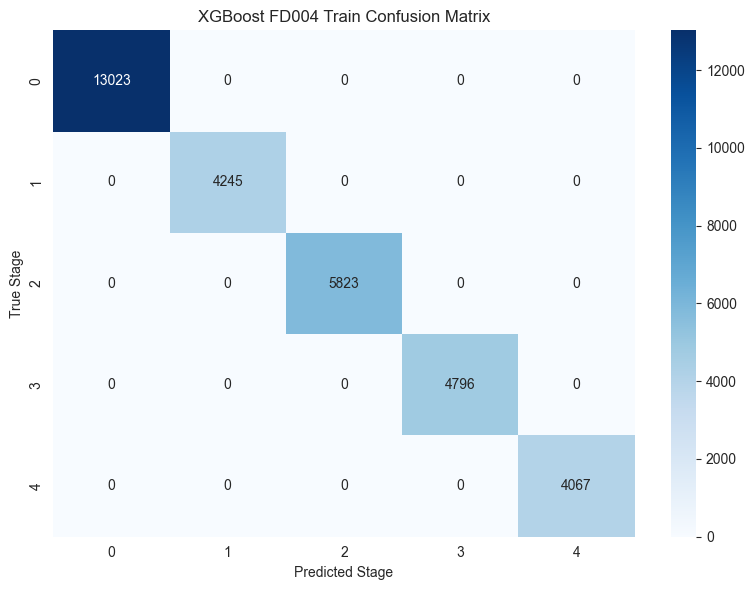

Saved: ..\..\figures\phase3\xgb_fd004_train_conf_matrix.png


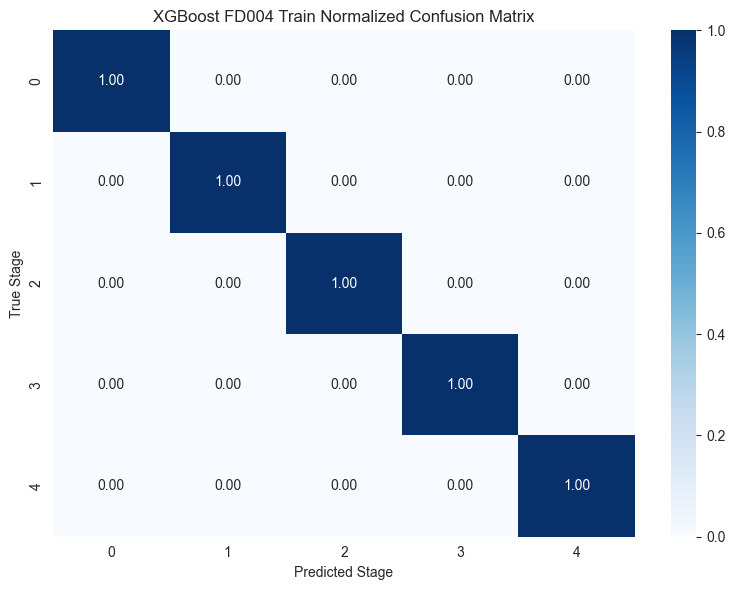

Saved: ..\..\figures\phase3\xgb_fd004_train_conf_matrix_normalized.png


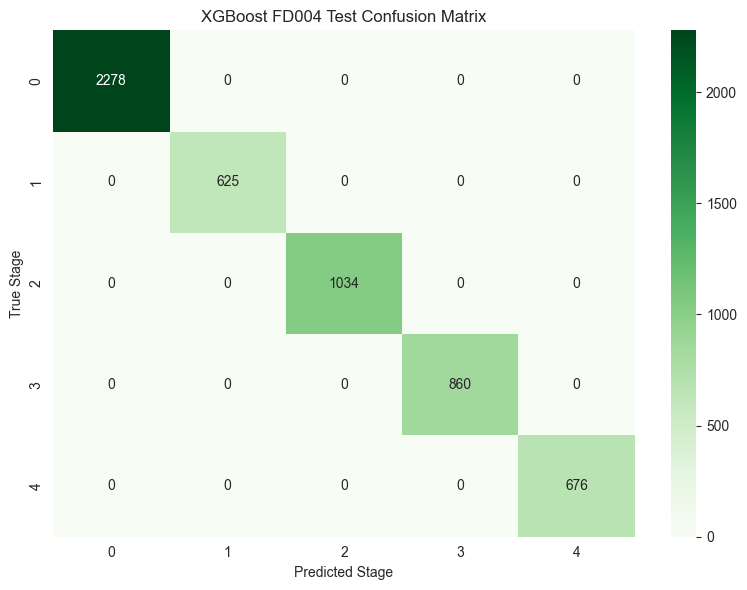

Saved: ..\..\figures\phase3\xgb_fd004_test_conf_matrix.png


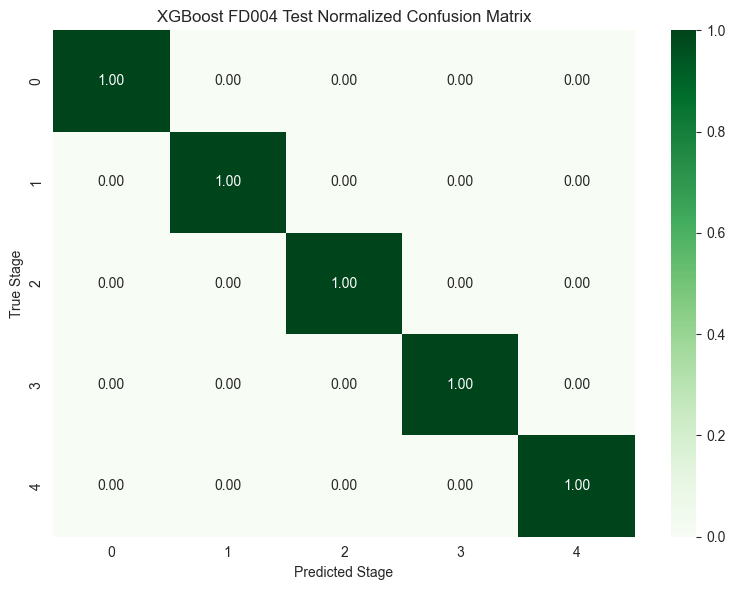

Saved: ..\..\figures\phase3\xgb_fd004_test_conf_matrix_normalized.png


In [14]:
# Step 8.0: Label Encoding for FD004
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os

label_encoder_fd004 = LabelEncoder()
y_train_fd004_encoded = label_encoder_fd004.fit_transform(y_train_fd004_clean)
y_test_fd004_encoded = label_encoder_fd004.transform(y_test_fd004_clean)
print("Label Encoding Done. Classes:", label_encoder_fd004.classes_)

# Step 8.1: XGBoost Classifier Training + Evaluation (FD004)
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

# 1. Initialize Model
xgb_model_fd004 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE
)

# 2. 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_xgb_fd004 = cross_val_score(
    xgb_model_fd004,
    X_train_fd004_clean,
    y_train_fd004_encoded,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("XGBoost 5-Fold CV F1 Macro Scores (FD004):", cv_scores_xgb_fd004)
print("Mean F1 Macro Score:", np.mean(cv_scores_xgb_fd004))

# 3. Train on full data
xgb_model_fd004.fit(X_train_fd004_clean, y_train_fd004_encoded)

# 4. Save the trained model
model_path = os.path.join('..', '..', 'models', 'xgb_fd004_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(xgb_model_fd004, model_path)
print(f"Trained XGBoost model saved at: {model_path}")

# Step 8.5: Predictions and Decoding
y_train_pred_encoded = xgb_model_fd004.predict(X_train_fd004_clean)
y_test_pred_encoded = xgb_model_fd004.predict(X_test_fd004_clean)

y_train_pred_decoded = label_encoder_fd004.inverse_transform(y_train_pred_encoded)
y_test_pred_decoded = label_encoder_fd004.inverse_transform(y_test_pred_encoded)
y_train_true_decoded = label_encoder_fd004.inverse_transform(y_train_fd004_encoded)
y_test_true_decoded = label_encoder_fd004.inverse_transform(y_test_fd004_encoded)

print(f"XGBoost Train Accuracy: {accuracy_score(y_train_true_decoded, y_train_pred_decoded):.4f}")
print(f"XGBoost Test Accuracy : {accuracy_score(y_test_true_decoded, y_test_pred_decoded):.4f}")

# Step 8.6: Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'xgb_fd004_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_true_decoded, y_train_pred_decoded))

with open(os.path.join(report_dir, 'xgb_fd004_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_true_decoded, y_test_pred_decoded))

print("Classification reports saved.")

# Step 8.7: Confusion Matrix Plotting
def save_conf_matrix(cm, title, filename, fmt, cmap):
    fig_dir = os.path.join('..', '..', 'figures', 'phase3')
    os.makedirs(fig_dir, exist_ok=True)
    path = os.path.join(fig_dir, filename)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f"Saved: {path}")

# Step 8.8: Save All Confusion Matrices
save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded),
                 "XGBoost FD004 Train Confusion Matrix", "xgb_fd004_train_conf_matrix.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded, normalize='true'),
                 "XGBoost FD004 Train Normalized Confusion Matrix", "xgb_fd004_train_conf_matrix_normalized.png", '.2f', 'Blues')

save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded),
                 "XGBoost FD004 Test Confusion Matrix", "xgb_fd004_test_conf_matrix.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded, normalize='true'),
                 "XGBoost FD004 Test Normalized Confusion Matrix", "xgb_fd004_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step A: Random Forest Hyperparameter Tuning (FD004)

In [15]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Load Corrected + Clustered FD004 Data
fd004_path = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD004.csv')
df_fd004 = pd.read_csv(fd004_path)
print("✅ Corrected FD004 dataset loaded successfully.")

# 2. Select Top 5 Sensor Features (based on variance analysis)
top5_sensors_fd004 = ['sensor_16', 'sensor_1', 'sensor_19', 'sensor_13', 'sensor_2']
X_fd004 = df_fd004[top5_sensors_fd004]
y_fd004 = df_fd004['kmeans_stage']
print("✅ Selected top 5 sensor features and kmeans_stage as target.")

# 3. Stratified Train-Test Split
X_train_fd004, X_test_fd004, y_train_fd004, y_test_fd004 = train_test_split(
    X_fd004,
    y_fd004,
    test_size=0.2,
    stratify=y_fd004,
    random_state=42
)
print(f"✅ Train/Test split complete. Train shape: {X_train_fd004.shape}, Test shape: {X_test_fd004.shape}")

# 4. Define Hyperparameter Grid
param_grid_rf_fd004 = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 5. Setup GridSearchCV
rf_base_model = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search_rf_fd004 = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid_rf_fd004,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2
)

# 6. Execute Grid Search
print("🔍 Starting Grid Search for FD004 Random Forest...")
grid_search_rf_fd004.fit(X_train_fd004, y_train_fd004)

# 7. Output Best Model Details
print("\n✅ Grid Search Completed.")
print("Best Parameters:", grid_search_rf_fd004.best_params_)
print("Best F1 Macro Score:", grid_search_rf_fd004.best_score_)

# 8. Retrain Final Model on Entire Training Data
best_rf_fd004 = grid_search_rf_fd004.best_estimator_
best_rf_fd004.fit(X_train_fd004, y_train_fd004)

# 9. Save the Best Model
model_save_path = os.path.abspath(os.path.join('..', '..', 'models', 'rf_fd004_best_model.pkl'))
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
joblib.dump(best_rf_fd004, model_save_path)
print(f"✅ Best Random Forest model saved at: {model_save_path}")


✅ Corrected FD004 dataset loaded successfully.
✅ Selected top 5 sensor features and kmeans_stage as target.
✅ Train/Test split complete. Train shape: (48999, 5), Test shape: (12250, 5)
🔍 Starting Grid Search for FD004 Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ Grid Search Completed.
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Macro Score: 1.0
✅ Best Random Forest model saved at: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_fd004_best_model.pkl


# Phase 3 (FD004) – Step B: Evaluation (Tuned Random Forest)


✅ Tuned Random Forest model loaded successfully for FD004.
✅ Data loaded and split for FD004 evaluation.
✅ RF Tuned Train Accuracy: 1.0000
✅ RF Tuned Test Accuracy : 1.0000
✅ Classification reports saved in: ..\..\report


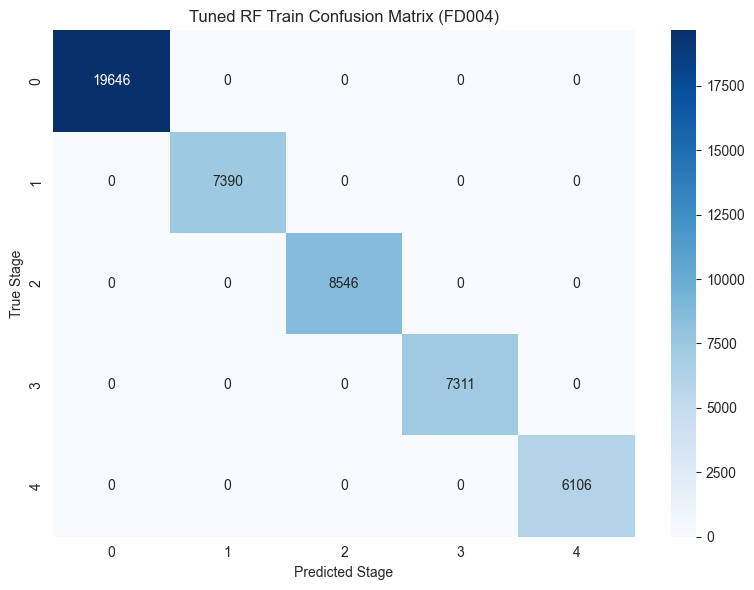

✅ Saved: ..\..\figures\phase3\rf_fd004_train_conf_matrix_tuned.png


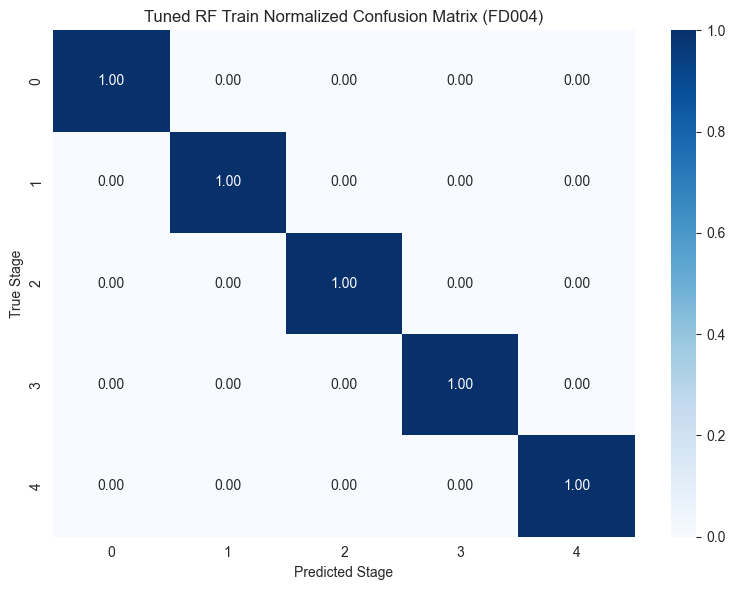

✅ Saved: ..\..\figures\phase3\rf_fd004_train_conf_matrix_normalized_tuned.png


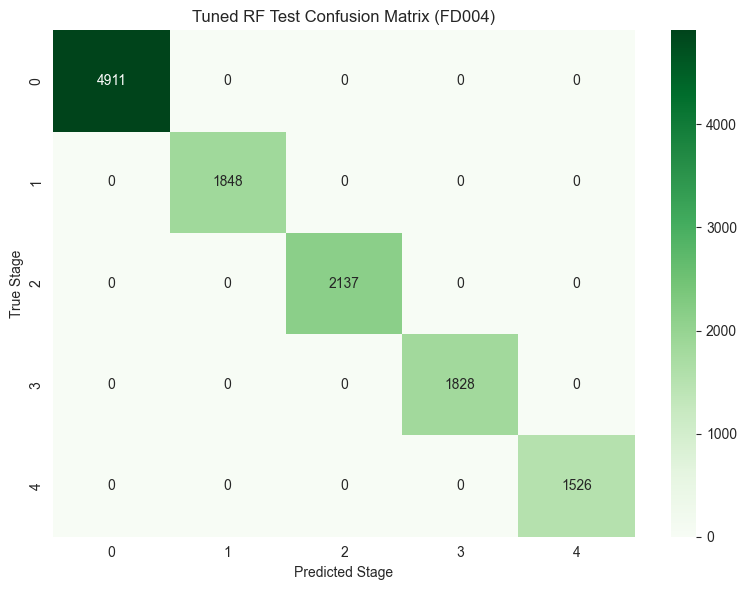

✅ Saved: ..\..\figures\phase3\rf_fd004_test_conf_matrix_tuned.png


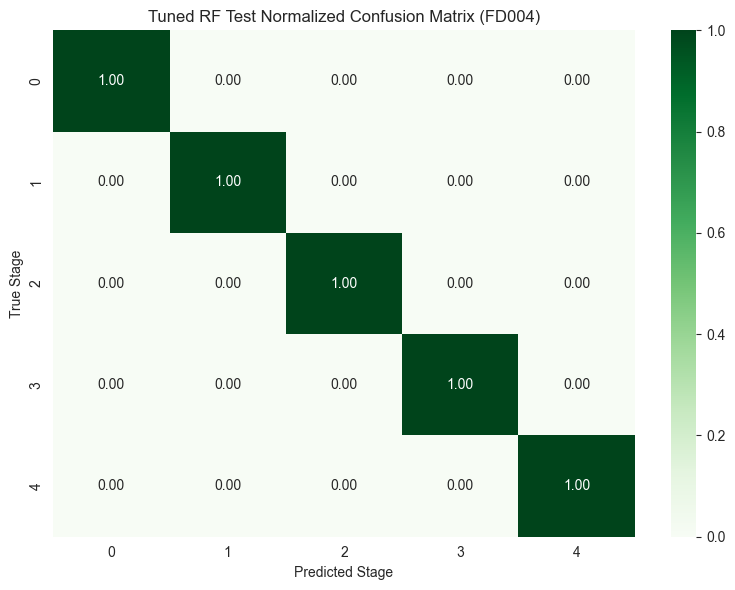

✅ Saved: ..\..\figures\phase3\rf_fd004_test_conf_matrix_normalized_tuned.png


In [16]:
# Phase 3 (FD004) – Step B: Evaluation (Tuned Random Forest)

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# 1. Load Tuned Random Forest Model
model_path = os.path.abspath(os.path.join('..', '..', 'models', 'rf_fd004_best_model.pkl'))
best_rf_fd004 = joblib.load(model_path)
print("✅ Tuned Random Forest model loaded successfully for FD004.")

# 2. Load Cleaned and Clustered FD004 Dataset
import pandas as pd

data_path = os.path.abspath(os.path.join('..', '..', 'data', 'corrected_clustered_train_FD004.csv'))
df_fd004 = pd.read_csv(data_path)

top5_sensors_fd004 = ['sensor_16', 'sensor_1', 'sensor_19', 'sensor_13', 'sensor_2']
X_fd004 = df_fd004[top5_sensors_fd004]
y_fd004 = df_fd004['kmeans_stage']

from sklearn.model_selection import train_test_split
X_train_fd004, X_test_fd004, y_train_fd004, y_test_fd004 = train_test_split(
    X_fd004,
    y_fd004,
    test_size=0.2,
    stratify=y_fd004,
    random_state=42
)
print("✅ Data loaded and split for FD004 evaluation.")

# 3. Predictions
y_train_pred = best_rf_fd004.predict(X_train_fd004)
y_test_pred = best_rf_fd004.predict(X_test_fd004)

# 4. Accuracy Scores
print(f"✅ RF Tuned Train Accuracy: {accuracy_score(y_train_fd004, y_train_pred):.4f}")
print(f"✅ RF Tuned Test Accuracy : {accuracy_score(y_test_fd004, y_test_pred):.4f}")

# 5. Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'rf_fd004_train_classification_report_tuned.txt'), 'w') as f:
    f.write(classification_report(y_train_fd004, y_train_pred))

with open(os.path.join(report_dir, 'rf_fd004_test_classification_report_tuned.txt'), 'w') as f:
    f.write(classification_report(y_test_fd004, y_test_pred))

print(f"✅ Classification reports saved in: {report_dir}")

# 6. Confusion Matrix Plotting Function
fig_dir = os.path.join('..', '..', 'figures', 'phase3')
os.makedirs(fig_dir, exist_ok=True)

def save_conf_matrix(cm, title, filename, fmt, cmap):
    path = os.path.join(fig_dir, filename)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f"✅ Saved: {path}")

# 7. Train Confusion Matrices
cm_train = confusion_matrix(y_train_fd004, y_train_pred)
cm_train_norm = confusion_matrix(y_train_fd004, y_train_pred, normalize='true')
save_conf_matrix(cm_train, "Tuned RF Train Confusion Matrix (FD004)", "rf_fd004_train_conf_matrix_tuned.png", 'd', 'Blues')
save_conf_matrix(cm_train_norm, "Tuned RF Train Normalized Confusion Matrix (FD004)", "rf_fd004_train_conf_matrix_normalized_tuned.png", '.2f', 'Blues')

# 8. Test Confusion Matrices
cm_test = confusion_matrix(y_test_fd004, y_test_pred)
cm_test_norm = confusion_matrix(y_test_fd004, y_test_pred, normalize='true')
save_conf_matrix(cm_test, "Tuned RF Test Confusion Matrix (FD004)", "rf_fd004_test_conf_matrix_tuned.png", 'd', 'Greens')
save_conf_matrix(cm_test_norm, "Tuned RF Test Normalized Confusion Matrix (FD004)", "rf_fd004_test_conf_matrix_normalized_tuned.png", '.2f', 'Greens')


# Phase 3 (FD004) – Step C: Confusion Matrices (Tuned Random Forest)

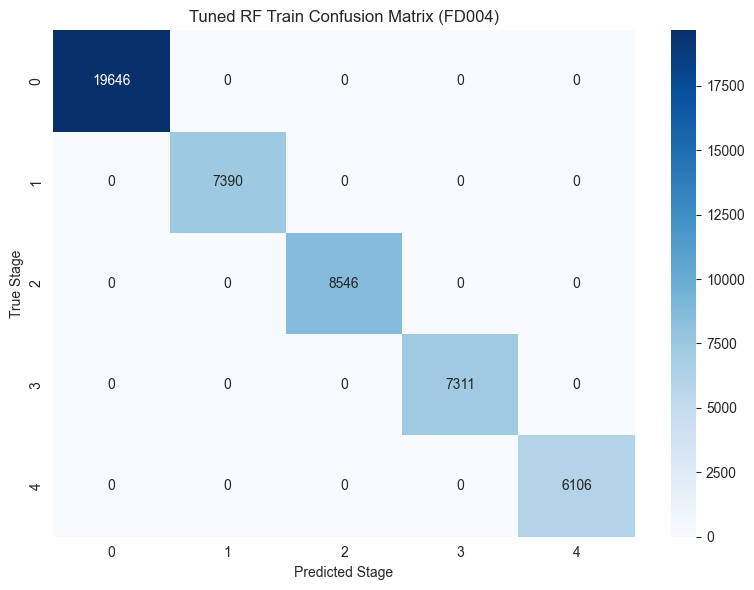

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_train_conf_matrix_tuned.png


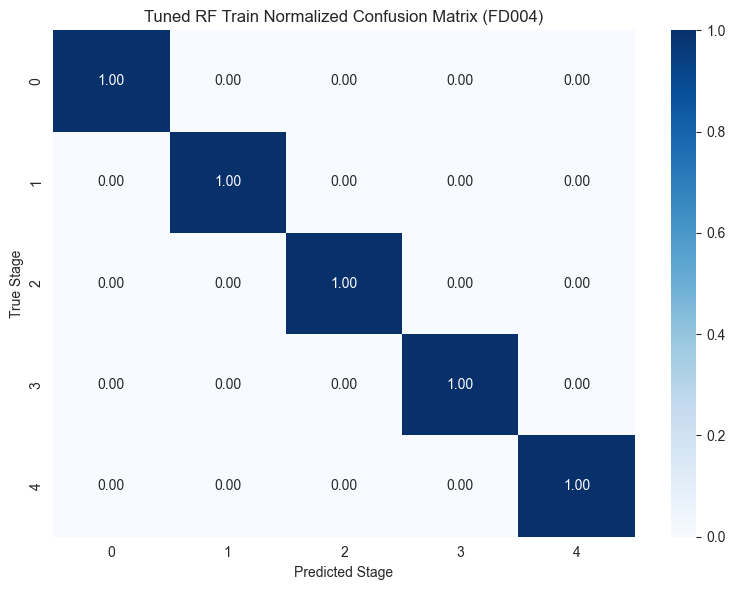

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_train_conf_matrix_normalized_tuned.png


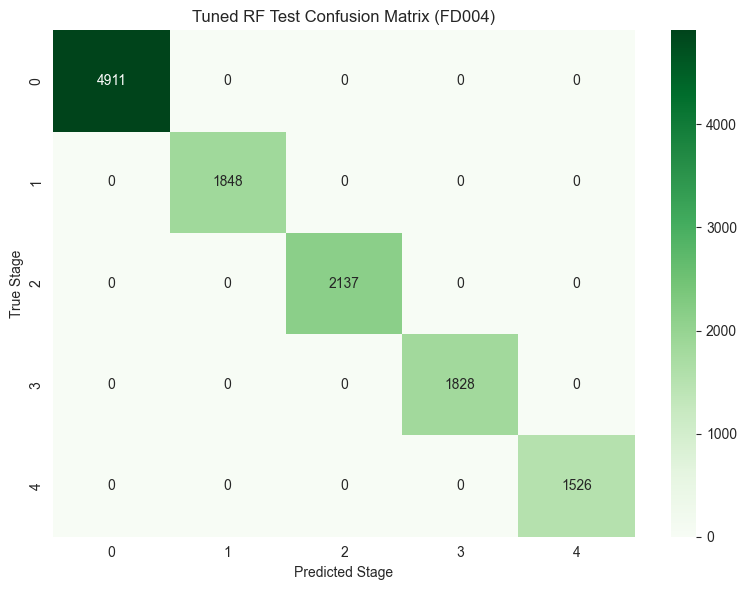

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_test_conf_matrix_tuned.png


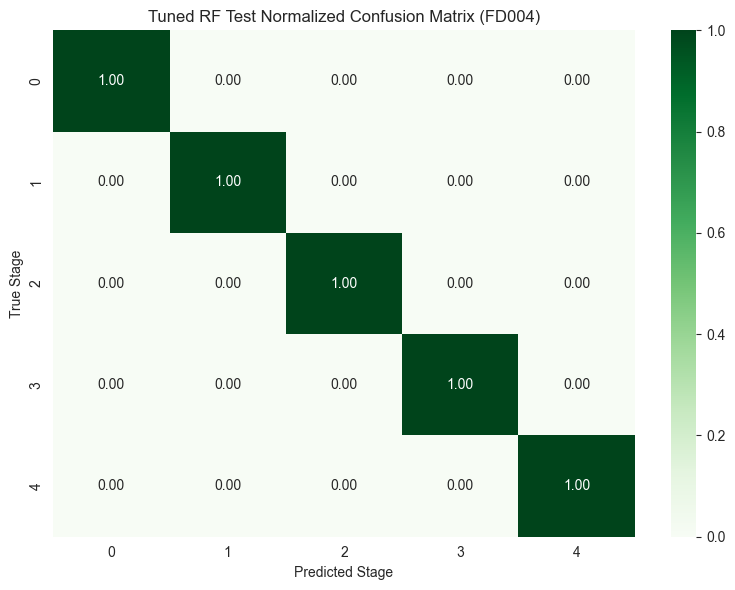

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd004_test_conf_matrix_normalized_tuned.png


In [17]:
# Phase 3 (FD004) – Step C: Confusion Matrices (Tuned Random Forest)

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Ensure figure directory exists
fig_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(fig_dir, exist_ok=True)

# 2. Define Confusion Matrix Plotting Function
def save_conf_matrix(cm, title, filename, fmt='d', cmap='Blues'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    fig_path = os.path.join(fig_dir, filename)
    plt.savefig(fig_path)
    plt.show()
    print(f"✅ Saved: {fig_path}")

# 3. Compute Train Confusion Matrices
cm_train_fd004 = confusion_matrix(y_train_fd004, y_train_pred)
cm_train_fd004_norm = confusion_matrix(y_train_fd004, y_train_pred, normalize='true')

save_conf_matrix(
    cm_train_fd004,
    "Tuned RF Train Confusion Matrix (FD004)",
    "rf_fd004_train_conf_matrix_tuned.png",
    fmt='d',
    cmap='Blues'
)

save_conf_matrix(
    cm_train_fd004_norm,
    "Tuned RF Train Normalized Confusion Matrix (FD004)",
    "rf_fd004_train_conf_matrix_normalized_tuned.png",
    fmt='.2f',
    cmap='Blues'
)

# 4. Compute Test Confusion Matrices
cm_test_fd004 = confusion_matrix(y_test_fd004, y_test_pred)
cm_test_fd004_norm = confusion_matrix(y_test_fd004, y_test_pred, normalize='true')

save_conf_matrix(
    cm_test_fd004,
    "Tuned RF Test Confusion Matrix (FD004)",
    "rf_fd004_test_conf_matrix_tuned.png",
    fmt='d',
    cmap='Greens'
)

save_conf_matrix(
    cm_test_fd004_norm,
    "Tuned RF Test Normalized Confusion Matrix (FD004)",
    "rf_fd004_test_conf_matrix_normalized_tuned.png",
    fmt='.2f',
    cmap='Greens'
)


# Phase 3 (FD004) – Final Step: Model Comparison Table and Bar Plot

Model Comparison Table (FD004):

                   Model  Train Accuracy  Test Accuracy  \
0  Random Forest (Tuned)             1.0            1.0   
1                    SVM             1.0            1.0   
2    Logistic Regression             1.0            1.0   
3                XGBoost             1.0            1.0   

   Mean F1 Macro Score (CV)  
0                    1.0000  
1                    1.0000  
2                    1.0000  
3                    0.9999  

Model Comparison Table saved at:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase3_model_comparison_fd004.csv


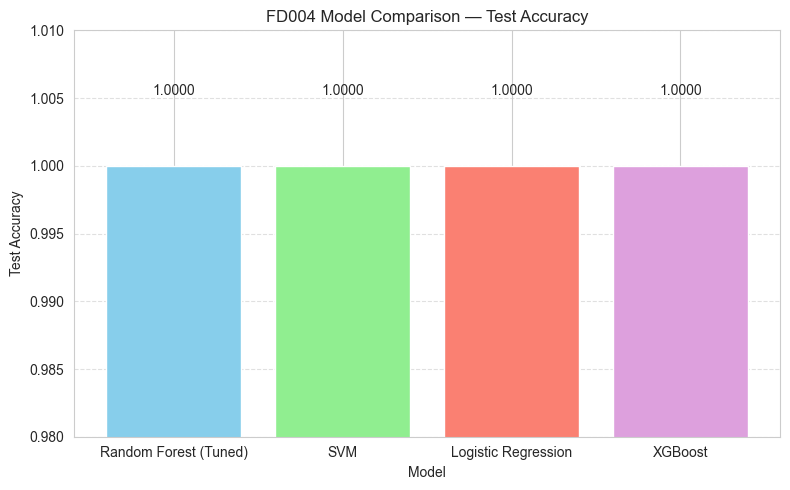


Bar Plot saved at:
c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\model_comparison_test_accuracy_fd004.png


In [18]:
# Phase 3 (FD004) – Final Step: Model Comparison Table and Bar Plot

import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Define Final Evaluation Results for FD004 (Corrected)
model_comparison_fd004 = {
    'Model': ['Random Forest (Tuned)', 'SVM', 'Logistic Regression', 'XGBoost'],
    'Train Accuracy': [
        1.0000,  # Tuned RF
        1.0000,  # SVM
        1.0000,  # Logistic Regression
        1.0000   # XGBoost
    ],
    'Test Accuracy': [
        1.0000,  # Tuned RF
        1.0000,  # SVM
        1.0000,  # Logistic Regression
        1.0000   # XGBoost
    ],
    'Mean F1 Macro Score (CV)': [
        1.0000,          # Tuned RF
        1.0000,          # SVM
        1.0000,          # Logistic Regression
        0.9999           # XGBoost (actual value was 0.9999164)
    ]
}

# 2. Create DataFrame
comparison_df_fd004 = pd.DataFrame(model_comparison_fd004)
print("Model Comparison Table (FD004):\n")
print(comparison_df_fd004)

# 3. Ensure output folders exist
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
report_dir = os.path.join(base_dir, 'report')
figures_dir = os.path.join(base_dir, 'figures', 'phase3')
os.makedirs(report_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# 4. Save table to CSV
comparison_csv_path = os.path.join(report_dir, 'phase3_model_comparison_fd004.csv')
comparison_df_fd004.to_csv(comparison_csv_path, index=False)
print(f"\nModel Comparison Table saved at:\n{comparison_csv_path}")

# 5. Bar Chart – Test Accuracy
plt.figure(figsize=(8, 5))
bar_colors = ['skyblue', 'lightgreen', 'salmon', 'plum']
bars = plt.bar(comparison_df_fd004['Model'], comparison_df_fd004['Test Accuracy'], color=bar_colors)

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.005,
             f'{height:.4f}', ha='center', va='bottom')

plt.ylim(0.98, 1.01)
plt.title('FD004 Model Comparison — Test Accuracy')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Save plot
plot_path = os.path.join(figures_dir, 'model_comparison_test_accuracy_fd004.png')
plt.savefig(plot_path)
plt.show()
print(f"\nBar Plot saved at:\n{plot_path}")
